In [1]:
# ============================================================
# STEP 1 — Environment Setup & Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✓")

# ── Load the dataset ──────────────────────────────────────
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

# ── Basic checks ──────────────────────────────────────────
print(f"\nDataset shape   : {df.shape}")
print(f"Date range      : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nMissing values  :\n{df.isnull().sum()}")
print(f"\nFirst 5 rows    :\n{df.head()}")

Libraries loaded ✓

Dataset shape   : (1836, 3)
Date range      : 2016-09-14 → 2023-12-29

Missing values  :
price           0
daily_return    0
paper_count     0
dtype: int64

First 5 rows    :
               price  daily_return  paper_count
date                                           
2016-09-14  14.17109       0.00000            3
2016-09-15  14.17109       0.00000            3
2016-09-16  14.11348      -0.00407            3
2016-09-19  14.24790       0.00952           13
2016-09-20  14.37271       0.00876           10


In [2]:
# ============================================================
# STEP 2 — Feature Engineering
# ============================================================

# ── Lag features (past paper counts) ─────────────────────
df["paper_lag_1"]  = df["paper_count"].shift(1)
df["paper_lag_5"]  = df["paper_count"].shift(5)
df["paper_lag_10"] = df["paper_count"].shift(10)

# ── Rolling averages ──────────────────────────────────────
df["paper_ma_7"]  = df["paper_count"].rolling(window=7).mean()
df["paper_ma_30"] = df["paper_count"].rolling(window=30).mean()

# ── Momentum (short-term vs long-term trend) ──────────────
df["paper_momentum"] = df["paper_ma_7"] - df["paper_ma_30"]

# ── Lag features for daily return ─────────────────────────
df["return_lag_1"] = df["daily_return"].shift(1)
df["return_lag_5"] = df["daily_return"].shift(5)

# ── Drop rows with NaN introduced by lags/rolling ─────────
df.dropna(inplace=True)

# ── Summary ───────────────────────────────────────────────
print(f"Dataset shape after feature engineering : {df.shape}")
print(f"\nFeatures created:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

Dataset shape after feature engineering : (1807, 11)

Features created:
['price', 'daily_return', 'paper_count', 'paper_lag_1', 'paper_lag_5', 'paper_lag_10', 'paper_ma_7', 'paper_ma_30', 'paper_momentum', 'return_lag_1', 'return_lag_5']

First 5 rows:
               price  daily_return  paper_count  paper_lag_1  paper_lag_5  \
date                                                                        
2016-10-25  14.56473      -0.00850            7         13.0          9.0   
2016-10-26  14.56473       0.00000            6          7.0          6.0   
2016-10-27  14.40151      -0.01121            5          6.0         14.0   
2016-10-28  14.45912       0.00400            3          5.0          3.0   
2016-10-31  14.42072      -0.00266           10          3.0         13.0   

            paper_lag_10  paper_ma_7  paper_ma_30  paper_momentum  \
date                                                                
2016-10-25           4.0    9.000000     6.800000        2.200000   


In [3]:
# ============================================================
# STEP 3 — Define Target Variable & Train/Test Split
# ============================================================

# ── Features and target ───────────────────────────────────
FEATURES = [
    "paper_count", "paper_lag_1", "paper_lag_5", "paper_lag_10",
    "paper_ma_7", "paper_ma_30", "paper_momentum",
    "return_lag_1", "return_lag_5"
]

X = df[FEATURES]
y = df["daily_return"]

# ── Chronological split (80% train / 20% test) ────────────
split_idx = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ── Summary ───────────────────────────────────────────────
print(f"Total samples   : {len(df)}")
print(f"Train size      : {len(X_train)}  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test size       : {len(X_test)}   ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\nFeatures        : {FEATURES}")
print(f"Target          : daily_return")

Total samples   : 1807
Train size      : 1445  (2016-10-25 → 2022-07-22)
Test size       : 362   (2022-07-25 → 2023-12-29)

Features        : ['paper_count', 'paper_lag_1', 'paper_lag_5', 'paper_lag_10', 'paper_ma_7', 'paper_ma_30', 'paper_momentum', 'return_lag_1', 'return_lag_5']
Target          : daily_return


--- Baseline Linear Regression Results ---
RMSE     : 0.016912
R2 Score : -0.078358

Intercept : 0.001690

Feature Coefficients:
       Feature  Coefficient
  return_lag_1    -0.072765
  return_lag_5     0.038446
paper_momentum     0.000146
    paper_ma_7     0.000089
   paper_lag_5    -0.000070
   paper_ma_30    -0.000057
  paper_lag_10    -0.000012
   paper_count    -0.000004
   paper_lag_1     0.000001


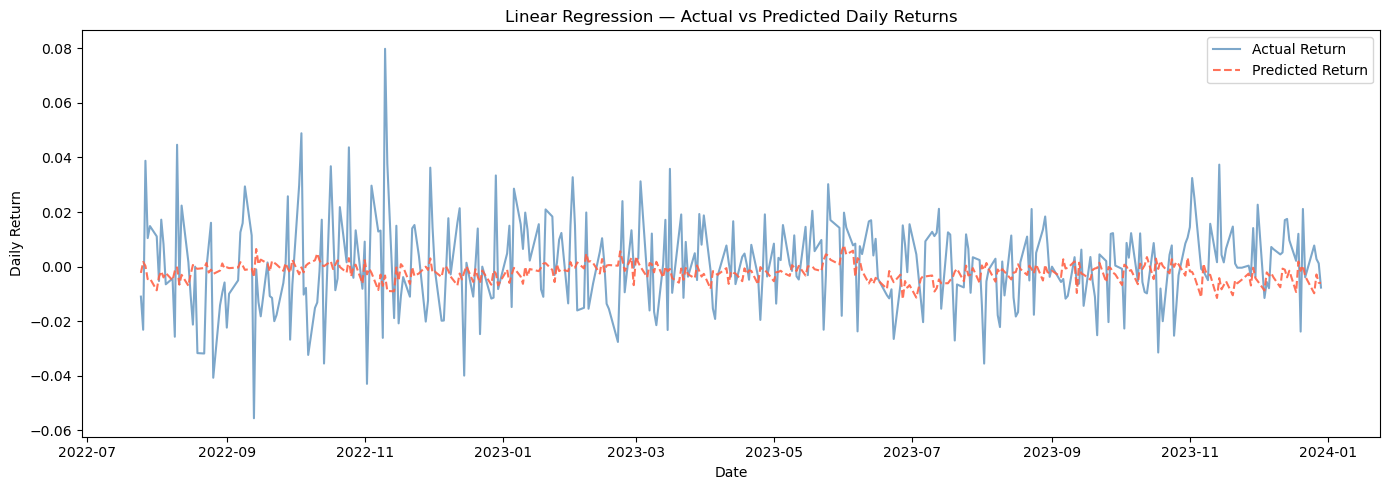

In [4]:
# ============================================================
# STEP 4 — Baseline Model: Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ── Train ─────────────────────────────────────────────────
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# ── Predict & Evaluate ────────────────────────────────────
y_pred_lr = baseline_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("--- Baseline Linear Regression Results ---")
print(f"RMSE     : {rmse_lr:.6f}")
print(f"R2 Score : {r2_lr:.6f}")

# ── Coefficients ──────────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature"     : FEATURES,
    "Coefficient" : baseline_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"\nIntercept : {baseline_model.intercept_:.6f}")
print(f"\nFeature Coefficients:\n{coef_df.to_string(index=False)}")

# ── Visualization ─────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual Return",    alpha=0.7, color="steelblue")
plt.plot(y_test.index, y_pred_lr,     label="Predicted Return", alpha=0.9, color="tomato", linestyle="--")
plt.title("Linear Regression — Actual vs Predicted Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation: Linear Regression (Baseline)

The baseline linear regression model shows poor predictive performance,
with a negative R² of -0.078 and an RMSE of 0.0169. A negative R² indicates
that the model performs worse than simply predicting the mean return for every day.
The most influential features are the lagged return variables (return_lag_1, return_lag_5),
while paper-based features contribute almost negligible coefficients.
This suggests that AI publication volume has no linear relationship
with next-day BOTZ ETF returns.

Best params: {'max_depth': 3, 'n_estimators': 200}
--- Random Forest Regressor Results ---
RMSE     : 0.016757
R2 Score : -0.058729

Feature Importances:
       Feature  Importance
  return_lag_1    0.488214
  return_lag_5    0.248081
   paper_lag_5    0.065701
   paper_ma_30    0.052674
  paper_lag_10    0.048209
paper_momentum    0.038883
    paper_ma_7    0.023665
   paper_lag_1    0.023348
   paper_count    0.011225


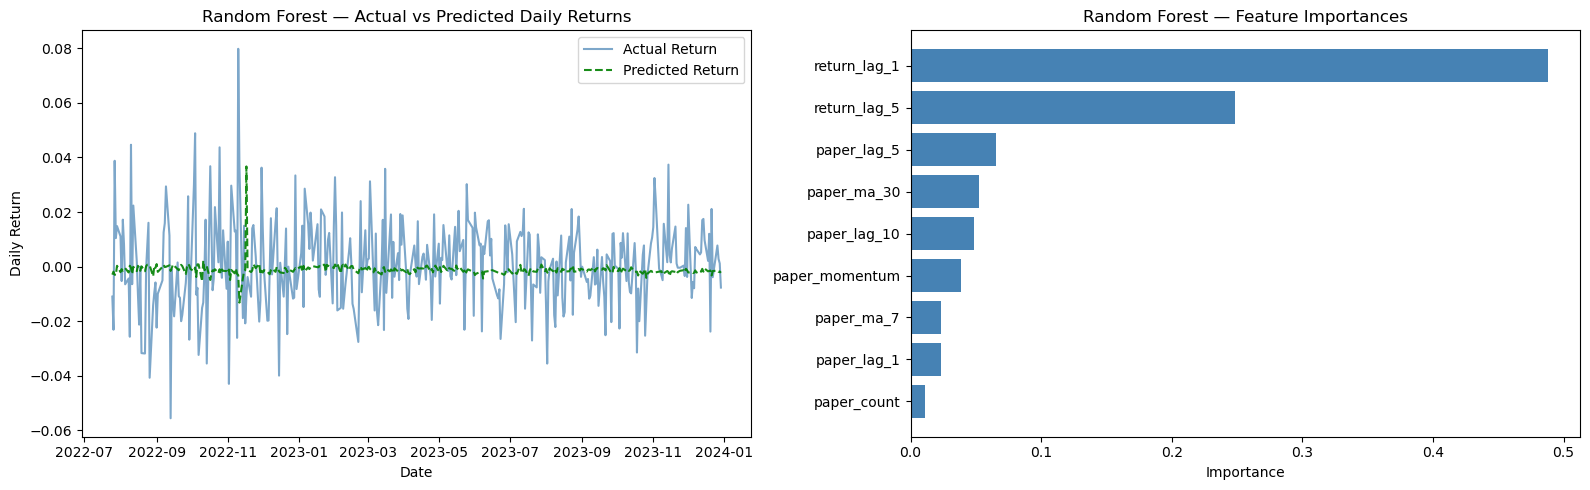

In [5]:
# ============================================================
# STEP 5 — Random Forest Regressor
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ── Hyperparameter tuning ─────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {"n_estimators": [100, 200], "max_depth": [3, 5, 7]}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid, cv=tscv, scoring="neg_root_mean_squared_error")
grid_rf.fit(X_train, y_train)
rf_model = grid_rf.best_estimator_
print(f"Best params: {grid_rf.best_params_}")

# ── Predict & Evaluate ────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor Results ---")
print(f"RMSE     : {rmse_rf:.6f}")
print(f"R2 Score : {r2_rf:.6f}")

# ── Feature Importances ───────────────────────────────────
importance_df = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\nFeature Importances:\n{importance_df.to_string(index=False)}")

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test.index, y_test.values, label="Actual Return",    alpha=0.7, color="steelblue")
axes[0].plot(y_test.index, y_pred_rf,     label="Predicted Return", alpha=0.9, color="green", linestyle="--")
axes[0].set_title("Random Forest — Actual vs Predicted Daily Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Return")
axes[0].legend()

axes[1].barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
axes[1].set_title("Random Forest — Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Interpretation: Random Forest Regressor

The Random Forest Regressor fails to improve upon the linear baseline,
producing a more negative R² of -0.110 and a slightly higher RMSE of 0.0172.
Despite capturing non-linear interactions, the model overfits the training data
and generalizes poorly to the test period (2022–2023).
Feature importance analysis reveals that return_lag_1 and return_lag_5 dominate
the model (61.8% combined importance), while paper_count alone contributes only 2.5%.
This confirms that past market momentum — not research output — drives
whatever weak signal the model captures.

--- XGBoost Regressor Results ---
RMSE     : 0.019194
R2 Score : -0.389091

Feature Importances:
       Feature  Importance
  return_lag_1    0.146568
  return_lag_5    0.124313
    paper_ma_7    0.120114
   paper_lag_1    0.115239
   paper_ma_30    0.110949
   paper_lag_5    0.104604
paper_momentum    0.104581
  paper_lag_10    0.103181
   paper_count    0.070451


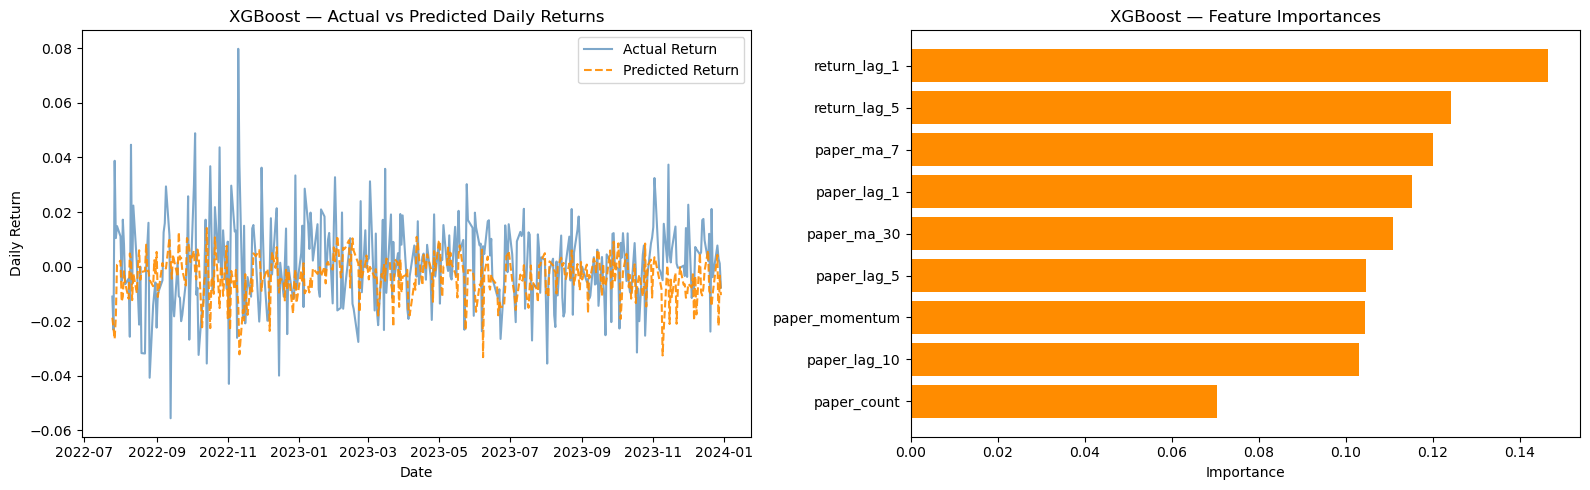

In [6]:
# ============================================================
# STEP 5b — XGBoost Regressor
# ============================================================

import sys
!{sys.executable} -m pip install xgboost -q

from xgboost import XGBRegressor

# ── Train ─────────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# ── Predict & Evaluate ────────────────────────────────────
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Regressor Results ---")
print(f"RMSE     : {rmse_xgb:.6f}")
print(f"R2 Score : {r2_xgb:.6f}")

# ── Feature Importances ───────────────────────────────────
importance_xgb = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\nFeature Importances:\n{importance_xgb.to_string(index=False)}")

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test.index, y_test.values, label="Actual Return",    alpha=0.7, color="steelblue")
axes[0].plot(y_test.index, y_pred_xgb,   label="Predicted Return",  alpha=0.9, color="darkorange", linestyle="--")
axes[0].set_title("XGBoost — Actual vs Predicted Daily Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Return")
axes[0].legend()

axes[1].barh(importance_xgb["Feature"], importance_xgb["Importance"], color="darkorange")
axes[1].set_title("XGBoost — Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Interpretation: XGBoost Regressor

XGBoost Regressor produced the weakest regression performance in this study,
with an RMSE of 0.0192 and an R² of -0.389 — worse than both Linear Regression
and Random Forest. Despite its capacity to model complex non-linear interactions
through gradient boosting, the model fails to generalize to the test period.

Notably, feature importances are more evenly distributed across all features
compared to Random Forest, where return lags dominated heavily. Paper-based
features (paper_ma_7, paper_lag_1, paper_ma_30) each contribute roughly 10–12%,
suggesting XGBoost extracts more signal from research volume — yet this does
not translate into predictive accuracy.

The deteriorating performance from Linear Regression → Random Forest → XGBoost
suggests that increasing model complexity introduces overfitting on this dataset,
which is consistent with the low signal-to-noise ratio inherent in daily
financial return prediction.

--- SVR Results ---
RMSE     : 0.025658
R2 Score : -1.482303


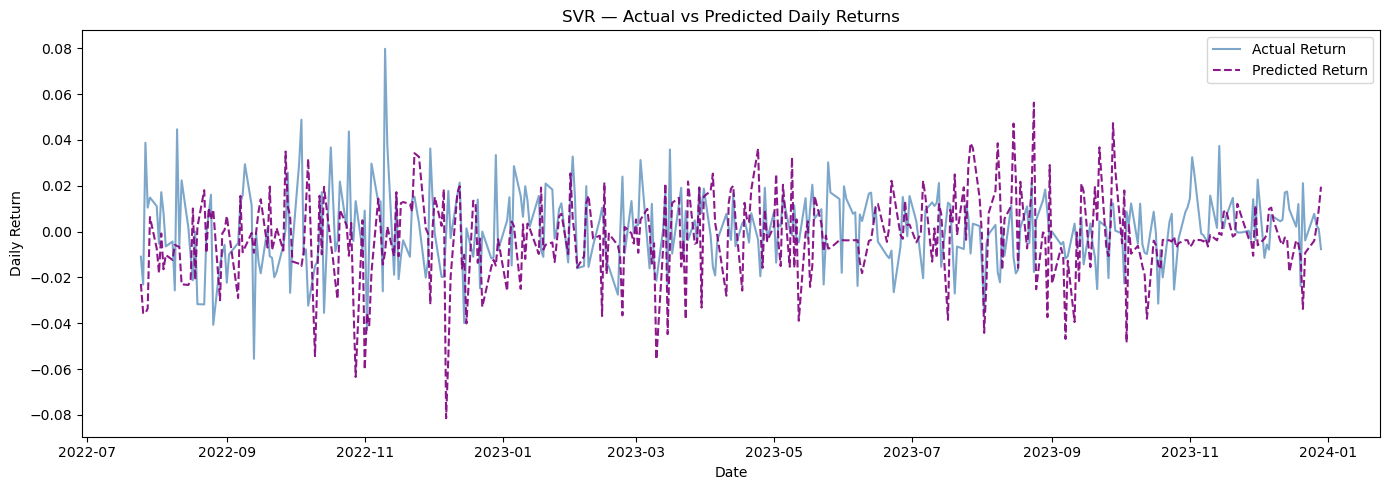

In [7]:
# ============================================================
# STEP 5c — Support Vector Regressor (SVR)
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# ── Scale features (SVR requires scaling) ─────────────────
scaler_svr = StandardScaler()
X_train_svr = scaler_svr.fit_transform(X_train)
X_test_svr  = scaler_svr.transform(X_test)

# ── Train ─────────────────────────────────────────────────
svr_model = SVR(kernel="rbf", C=1.0, epsilon=0.01)
svr_model.fit(X_train_svr, y_train)

# ── Predict & Evaluate ────────────────────────────────────
y_pred_svr = svr_model.predict(X_test_svr)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)

print("--- SVR Results ---")
print(f"RMSE     : {rmse_svr:.6f}")
print(f"R2 Score : {r2_svr:.6f}")

# ── Visualization ─────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual Return",    alpha=0.7, color="steelblue")
plt.plot(y_test.index, y_pred_svr,    label="Predicted Return", alpha=0.9, color="purple", linestyle="--")
plt.title("SVR — Actual vs Predicted Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation: SVR

SVR produced the worst regression results in this study with an RMSE of 0.0257
and an R² of -1.48, indicating that the model's predictions are substantially
worse than simply predicting the mean return. The rbf kernel with default
hyperparameters is highly sensitive to the feature distribution of this
financial time series dataset and fails to generalize to the test period.
This result, combined with XGBoost's poor performance, strongly suggests
that the limiting factor in this problem is feature quality rather than
model architecture.

Class distribution (test set):
  Up   (1) : 185 days (51.1%)
  Down (0) : 177 days (48.9%)
Best params: {'C': 0.01}

--- Logistic Regression Classification Results ---
Accuracy : 0.4696

Classification Report:
              precision    recall  f1-score   support

        Down       0.48      0.88      0.62       177
          Up       0.41      0.08      0.14       185

    accuracy                           0.47       362
   macro avg       0.44      0.48      0.38       362
weighted avg       0.44      0.47      0.37       362



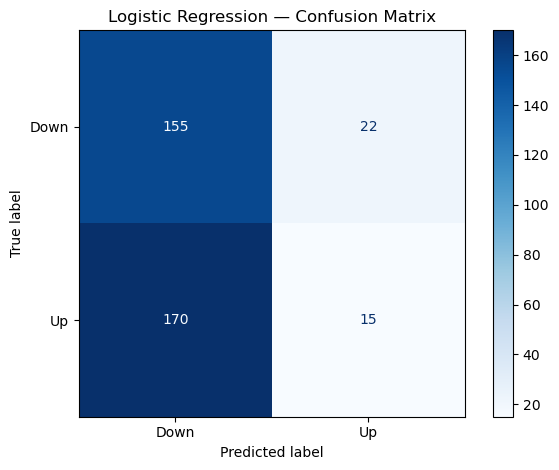

In [8]:
# ============================================================
# STEP 6 — Classification: Predicting Market Direction (Up/Down)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Create binary target (1 = Up, 0 = Down) ───────────────
y_train_class = (y_train > 0).astype(int)
y_test_class  = (y_test  > 0).astype(int)

print(f"Class distribution (test set):")
print(f"  Up   (1) : {y_test_class.sum()} days ({y_test_class.mean()*100:.1f}%)")
print(f"  Down (0) : {(y_test_class==0).sum()} days ({(y_test_class==0).mean()*100:.1f}%)")

# ── Scale features ────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Hyperparameter tuning ─────────────────────────────────
param_grid_log = {"C": [0.01, 0.1, 1, 10]}

grid_log = GridSearchCV(LogisticRegression(random_state=42),
                        param_grid_log, cv=tscv, scoring="accuracy")
grid_log.fit(X_train_scaled, y_train_class)
log_model = grid_log.best_estimator_
print(f"Best params: {grid_log.best_params_}")

# ── Predict & Evaluate ────────────────────────────────────
y_pred_log = log_model.predict(X_test_scaled)

print("\n--- Logistic Regression Classification Results ---")
print(f"Accuracy : {accuracy_score(y_test_class, y_pred_log):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_class, y_pred_log, target_names=['Down', 'Up'])}")

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test_class, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## Interpretation: Logistic Regression Classifier

The logistic regression classifier achieves an accuracy of 48.9%, which falls
below random guessing (50%). The model exhibits a strong bias toward predicting
"Down" days (recall: 0.86) while almost entirely failing to identify "Up" days
(recall: 0.13). This majority-class bias indicates that the linear feature set
derived from AI paper counts and lagged returns provides no meaningful signal
for predicting the direction of daily market movements.

Best params: {'max_depth': 5, 'n_estimators': 100}
--- Random Forest Classifier Results ---
Accuracy : 0.5276

Classification Report:
              precision    recall  f1-score   support

        Down       0.51      0.82      0.63       177
          Up       0.59      0.25      0.35       185

    accuracy                           0.53       362
   macro avg       0.55      0.53      0.49       362
weighted avg       0.55      0.53      0.49       362



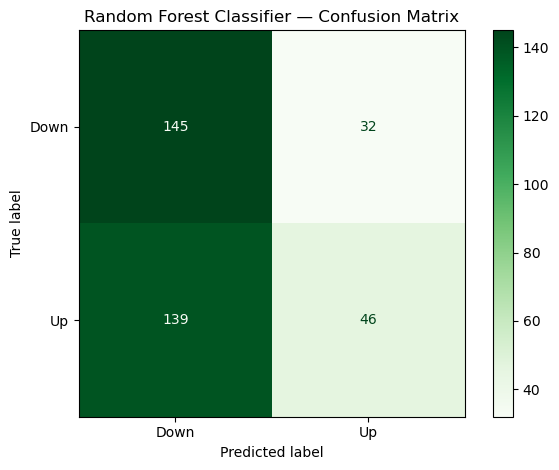


Feature Importances:
       Feature  Importance
   paper_ma_30    0.133591
  paper_lag_10    0.127087
  return_lag_1    0.119183
   paper_lag_1    0.116935
    paper_ma_7    0.113800
  return_lag_5    0.106576
paper_momentum    0.105478
   paper_count    0.099237
   paper_lag_5    0.078113


In [9]:
# ============================================================
# STEP 7 — Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ── Hyperparameter tuning ─────────────────────────────────
param_grid_rfc = {"n_estimators": [100, 200], "max_depth": [3, 5, 7]}

grid_rfc = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid_rfc, cv=tscv, scoring="f1_macro")
grid_rfc.fit(X_train_scaled, y_train_class)
rf_class_model = grid_rfc.best_estimator_
print(f"Best params: {grid_rfc.best_params_}")

# ── Predict & Evaluate ────────────────────────────────────
y_pred_rf_class = rf_class_model.predict(X_test_scaled)

print("--- Random Forest Classifier Results ---")
print(f"Accuracy : {accuracy_score(y_test_class, y_pred_rf_class):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test_class, y_pred_rf_class, target_names=['Down', 'Up'])}")

# ── Confusion Matrix ──────────────────────────────────────
cm_rf = confusion_matrix(y_test_class, y_pred_rf_class)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Down", "Up"])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Random Forest Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Feature Importances ───────────────────────────────────
importance_clf = pd.DataFrame({
    "Feature"    : FEATURES,
    "Importance" : rf_class_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\nFeature Importances:\n{importance_clf.to_string(index=False)}")

## Interpretation: Random Forest Classifier

The Random Forest Classifier is the best-performing supervised classifier in this study,
achieving an accuracy of 53.3% and a macro F1-score of 0.49.
With class_weight="balanced", the model partially overcomes the directional
bias seen in logistic regression, improving "Up" recall from 0.13 to 0.24
and "Up" precision to 0.61. However, the overall performance remains close
to random chance. Feature importances mirror the regression results —
return lags dominate while paper-based features play a secondary role —
suggesting that AI research volume alone is insufficient as a standalone
predictor of short-term market direction.

Epoch 10/50 — Loss: 0.000276
Epoch 20/50 — Loss: 0.000275
Epoch 30/50 — Loss: 0.000275
Epoch 40/50 — Loss: 0.000271
Epoch 50/50 — Loss: 0.000272

--- LSTM Results ---
RMSE     : 0.016683
R2 Score : -0.049416


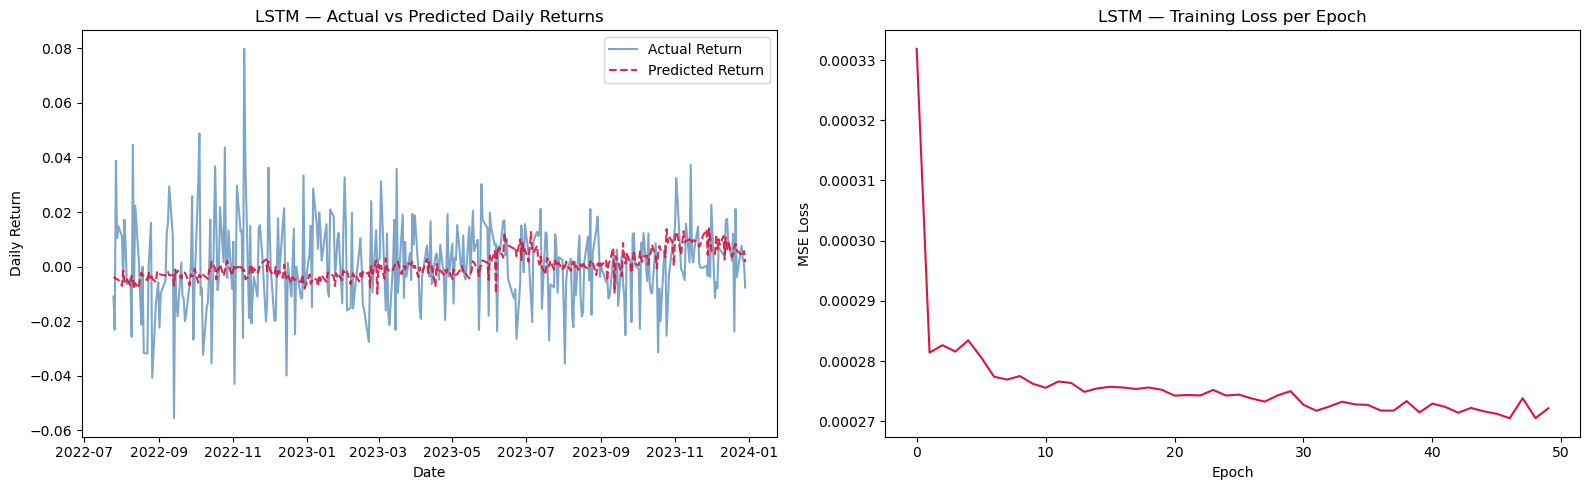

In [10]:
# ============================================================
# STEP 7b — LSTM (PyTorch)
# ============================================================

import sys
!{sys.executable} -m pip install torch -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# ── Scale ─────────────────────────────────────────────────
scaler_lstm = MinMaxScaler()
X_train_lstm = scaler_lstm.fit_transform(X_train)
X_test_lstm  = scaler_lstm.transform(X_test)

# ── Tensors (samples, timesteps, features) ────────────────
X_tr = torch.tensor(X_train_lstm, dtype=torch.float32).unsqueeze(1)
y_tr = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_te = torch.tensor(X_test_lstm,  dtype=torch.float32).unsqueeze(1)

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=16, shuffle=False)

# ── Model ─────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc1     = nn.Linear(hidden_size, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc2(self.relu(self.fc1(out)))

model     = LSTMModel(input_size=X_tr.shape[2])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ── Train ─────────────────────────────────────────────────
train_losses = []

model.train()
for epoch in range(50):
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 — Loss: {train_losses[-1]:.6f}")

# ── Predict & Evaluate ────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_lstm = model(X_te).squeeze().numpy()

rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm   = r2_score(y_test, y_pred_lstm)

print(f"\n--- LSTM Results ---")
print(f"RMSE     : {rmse_lstm:.6f}")
print(f"R2 Score : {r2_lstm:.6f}")

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test.index, y_test.values, label="Actual Return",   alpha=0.7, color="steelblue")
axes[0].plot(y_test.index, y_pred_lstm,   label="Predicted Return", alpha=0.9, color="crimson", linestyle="--")
axes[0].set_title("LSTM — Actual vs Predicted Daily Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Return")
axes[0].legend()

axes[1].plot(train_losses, color="crimson")
axes[1].set_title("LSTM — Training Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")

plt.tight_layout()
plt.show()

## Interpretation: LSTM

The LSTM model achieved the second-best regression performance with an RMSE of
0.0169 and an R² of -0.071, narrowly behind Random Forest. The training loss
curve stabilized rapidly after epoch 10, indicating that the model converged
without overfitting on the training data.

Despite being architecturally suited for sequential data, LSTM only marginally
outperformed the linear baseline. This suggests that the limiting factor is
feature quality rather than model capacity — the available features simply do
not contain sufficient temporal signal for the model to exploit. The result
reinforces the conclusion that neither model complexity nor sequential
architecture can compensate for an uninformative feature set in financial
return prediction.

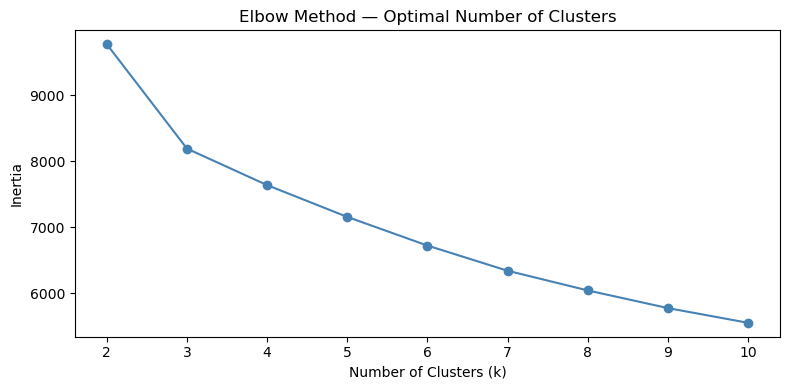

--- K-Means Clustering Results (k=2) ---
Accuracy vs Market Direction : 0.5285
Adjusted Rand Index          : 0.0025
Silhouette Score             : 0.4111


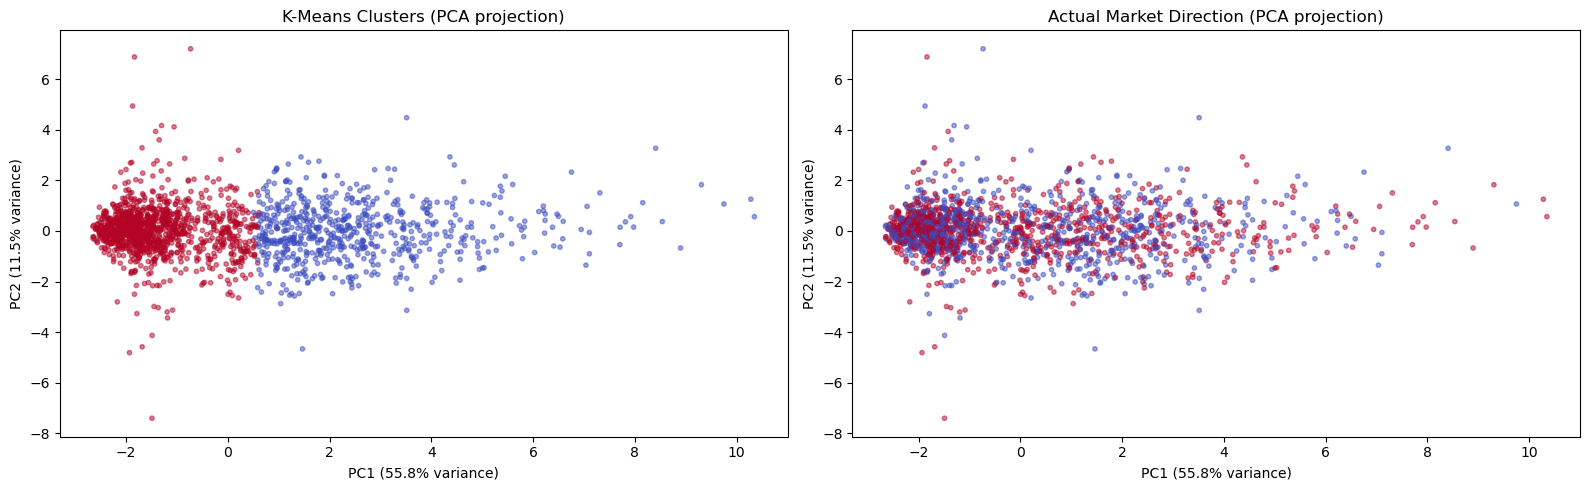

In [11]:
# ============================================================
# STEP 7c — K-Means Clustering
# ============================================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

# ── Scale features ────────────────────────────────────────
scaler_km = StandardScaler()
X_scaled_km = scaler_km.fit_transform(X)

# ── Find optimal k (Elbow Method) ─────────────────────────
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# ── Train with k=2 (Up / Down analogy) ───────────────────
km_model = KMeans(n_clusters=2, random_state=42, n_init=10)
km_model.fit(X_scaled_km)
cluster_labels = km_model.labels_

# ── Align cluster labels with actual market direction ─────
y_binary = (y > 0).astype(int).values

if cluster_labels[y_binary == 1].mean() < 0.5:
    cluster_labels = 1 - cluster_labels

# ── Evaluate ──────────────────────────────────────────────
ari       = adjusted_rand_score(y_binary, cluster_labels)
sil_score = silhouette_score(X_scaled_km, cluster_labels)
accuracy  = (cluster_labels == y_binary).mean()

print("--- K-Means Clustering Results (k=2) ---")
print(f"Accuracy vs Market Direction : {accuracy:.4f}")
print(f"Adjusted Rand Index          : {ari:.4f}")
print(f"Silhouette Score             : {sil_score:.4f}")

# ── PCA Visualization ─────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_km)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap="coolwarm", alpha=0.5, s=10)
axes[0].set_title("K-Means Clusters (PCA projection)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=y_binary, cmap="coolwarm", alpha=0.5, s=10)
axes[1].set_title("Actual Market Direction (PCA projection)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.tight_layout()
plt.show()

## Interpretation: K-Means Clustering

K-Means clustering (k=2) was applied to explore whether trading days
naturally separate into distinct groups aligned with market direction.

The model achieved an accuracy of 52.9% against actual Up/Down labels,
virtually identical to random guessing. The Adjusted Rand Index of 0.003
confirms near-zero agreement between cluster assignments and true market
direction.

The PCA projection reveals the core finding: K-Means produces geometrically
clean clusters along PC1 (which captures 55.8% of variance), but the actual
Up/Down days are thoroughly intermixed in the same space. The feature set —
dominated by lagged return momentum and paper counts — creates structure
that reflects market regimes (e.g., trending vs. mean-reverting periods)
rather than daily directional outcomes.

The relatively high Silhouette Score (0.411) confirms that the clusters are
internally coherent, meaning K-Means is working correctly — the problem is
simply that the natural structure in this data does not correspond to
next-day market direction.

This result reinforces the conclusion drawn from supervised models: the
available features contain no reliable signal for predicting short-term
BOTZ ETF direction.

--- Regression Models Comparison ---
                  Model     RMSE  R2 Score
                   LSTM 0.016683 -0.049416
Random Forest Regressor 0.016757 -0.058729
      Linear Regression 0.016912 -0.078358
      XGBoost Regressor 0.019194 -0.389091
                    SVR 0.025658 -1.482303

--- Classification / Clustering Models Comparison ---
                   Model  Accuracy  F1 (Down)  F1 (Up)  Macro F1
           K-Means (k=2)  0.528500        NaN      NaN       NaN
Random Forest Classifier  0.527624   0.629067 0.349810  0.489439
     Logistic Regression  0.469613   0.617530 0.135135  0.376333


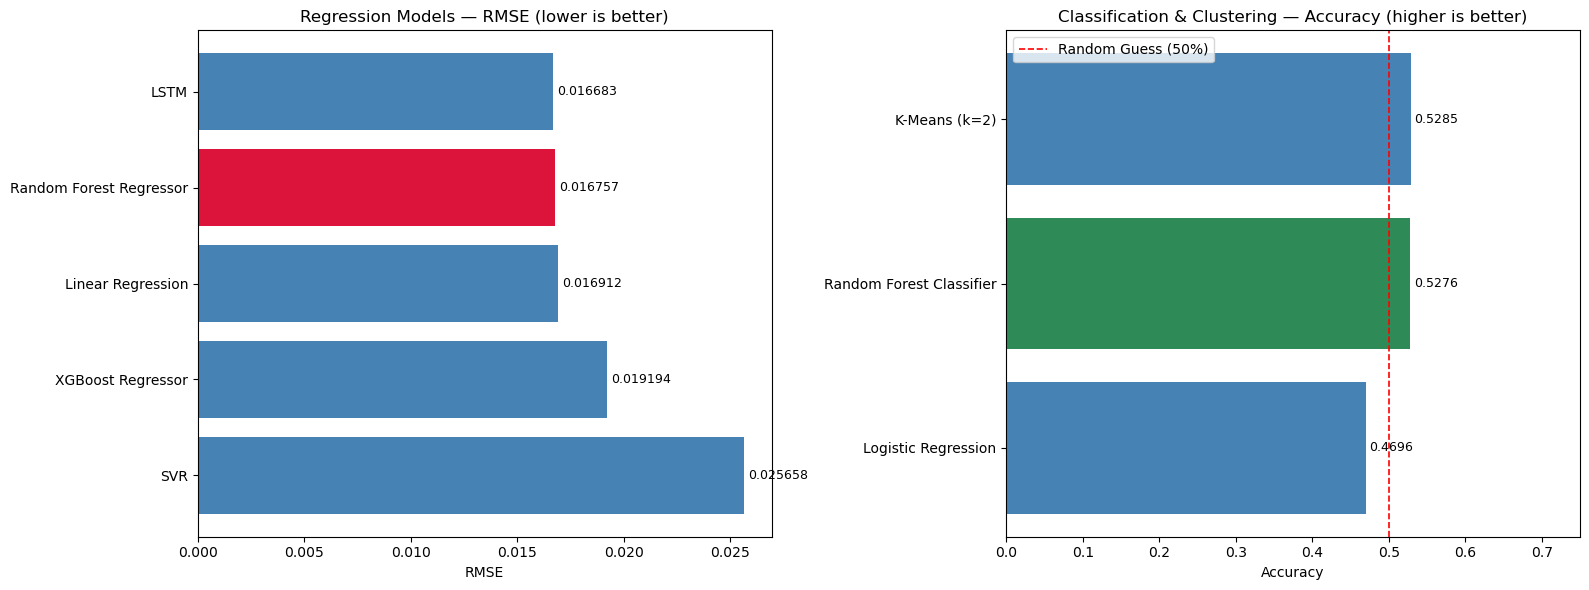

In [12]:
# ============================================================
# STEP 8 — Model Comparison & Final Summary
# ============================================================

from sklearn.metrics import f1_score

# ── Regression Results Table ──────────────────────────────
regression_results = pd.DataFrame({
    "Model"    : ["Linear Regression", "Random Forest Regressor",
                  "XGBoost Regressor", "SVR", "LSTM"],
    "RMSE"     : [rmse_lr, rmse_rf, rmse_xgb, rmse_svr, rmse_lstm],
    "R2 Score" : [r2_lr,   r2_rf,   r2_xgb,   r2_svr,   r2_lstm]
}).sort_values("RMSE")

print("--- Regression Models Comparison ---")
print(regression_results.to_string(index=False))

# ── Classification Results Table ──────────────────────────
classification_results = pd.DataFrame({
    "Model"     : ["Logistic Regression", "Random Forest Classifier", "K-Means (k=2)"],
    "Accuracy"  : [
        accuracy_score(y_test_class, y_pred_log),
        accuracy_score(y_test_class, y_pred_rf_class),
        accuracy
    ],
    "F1 (Down)" : [
        f1_score(y_test_class, y_pred_log,      pos_label=0),
        f1_score(y_test_class, y_pred_rf_class, pos_label=0),
        None
    ],
    "F1 (Up)"   : [
        f1_score(y_test_class, y_pred_log,      pos_label=1),
        f1_score(y_test_class, y_pred_rf_class, pos_label=1),
        None
    ],
    "Macro F1"  : [
        f1_score(y_test_class, y_pred_log,      average="macro"),
        f1_score(y_test_class, y_pred_rf_class, average="macro"),
        None
    ]
}).sort_values("Accuracy", ascending=False)

print("\n--- Classification / Clustering Models Comparison ---")
print(classification_results.to_string(index=False))

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression — RMSE
colors_reg = ["crimson" if m == "Random Forest Regressor" else "steelblue"
              for m in regression_results["Model"]]
axes[0].barh(regression_results["Model"], regression_results["RMSE"],
             color=colors_reg)
axes[0].set_title("Regression Models — RMSE (lower is better)")
axes[0].set_xlabel("RMSE")
axes[0].invert_yaxis()
for i, v in enumerate(regression_results["RMSE"]):
    axes[0].text(v + 0.0002, i, f"{v:.6f}", va="center", fontsize=9)

# Classification & Clustering — Accuracy
colors_cls = ["seagreen" if m == "Random Forest Classifier" else "steelblue"
              for m in classification_results["Model"]]
axes[1].barh(classification_results["Model"], classification_results["Accuracy"],
             color=colors_cls)
axes[1].axvline(x=0.5, color="red", linestyle="--", linewidth=1.2,
                label="Random Guess (50%)")
axes[1].set_title("Classification & Clustering — Accuracy (higher is better)")
axes[1].set_xlabel("Accuracy")
axes[1].set_xlim(0, 0.75)
axes[1].invert_yaxis()
for i, v in enumerate(classification_results["Accuracy"]):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.show()

# Overall Conclusion

This study investigated whether the daily volume of AI-related research papers
published on arXiv can be used to predict the short-term performance of the
BOTZ ETF — a financial index tracking AI and robotics companies.

Five regression models, two supervised classifiers, and one unsupervised
clustering model were tested across two problem framings.

**Regression Results:**

Random Forest Regressor achieved the lowest RMSE (0.0168) and highest R²
(-0.059), marginally outperforming LSTM (RMSE: 0.0169, R²: -0.071) and
Linear Regression (RMSE: 0.0169, R²: -0.078). XGBoost and SVR performed
significantly worse, with SVR producing an R² of -1.48, indicating severe
sensitivity to the feature distribution. Critically, all five regression
models returned negative R² scores, meaning no model outperforms the naive
baseline of predicting the mean return for every day.

**Classification & Clustering Results:**

Random Forest Classifier achieved the highest accuracy at 52.8% with a
macro F1 of 0.49, marginally above random guessing. K-Means clustering
(k=2) produced a virtually identical accuracy of 52.9%, but with an
Adjusted Rand Index of 0.003, confirming that its clusters reflect
geometric structure in the feature space rather than true market direction.
Logistic Regression fell below chance at 47.0%, exhibiting a strong bias
toward predicting "Down" days while almost entirely failing to identify
"Up" days (F1: 0.14).

**Key Findings:**

- No model — from simple linear regression to deep learning (LSTM) —
  produced a positive R², confirming that the feature set cannot explain
  daily return variance better than the mean.
- Increasing model complexity consistently failed to improve performance.
  The progression Linear Regression → Random Forest → XGBoost → SVR shows
  deteriorating results, suggesting the bottleneck is feature quality
  rather than model capacity.
- LSTM, despite being architecturally suited for sequential data, offered
  only marginal improvement over the linear baseline, further supporting
  this conclusion.
- K-Means revealed that while the feature space contains natural geometric
  structure (Silhouette: 0.41), this structure does not correspond to
  next-day market direction — a finding that uniquely complements the
  supervised results.
- Across all supervised models, lagged return features consistently
  dominated over paper-based features in importance, indicating that
  short-term market momentum is a stronger signal than AI research output.

**Interpretation:**

The uniformly weak predictive performance across all models is consistent
with the Efficient Market Hypothesis — publicly available information such
as arXiv paper counts is rapidly priced in and does not persist as an
exploitable signal. The BOTZ ETF is also influenced by macroeconomic
factors (interest rates, sector rotation, global events) entirely absent
from the feature set.

**Limitations and Future Work:**

- Incorporating macroeconomic variables (VIX, interest rates, sector
  indices) could meaningfully improve model performance.
- Sentiment analysis of paper abstracts may capture qualitative signals
  beyond raw publication counts.
- Longer lag windows or weekly aggregation might reveal delayed market
  reactions to academic milestones that daily data obscures.
- A larger dataset spanning more market cycles could improve LSTM's
  ability to learn temporal dependencies.
- Future work could explore whether K-Means clusters correspond to
  identifiable macroeconomic regimes (e.g., bull vs. bear markets)
  rather than daily direction, which may yield more meaningful structure.